In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [2]:
edges_df = pd.read_csv("enron_weighted_edges.csv")
# remove self-loops
edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

# Get the full network
G_full = (nx.from_pandas_edgelist
    (edges_df,
    source='Source',
    target='Target',
    edge_attr='Weight',
    create_using=nx.DiGraph()))
print(f"Enron dataset: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")

Enron dataset: 56595 nodes, 226837 edges


In [3]:
# get subgraph of active user with degree >= 10
nodes_to_keep = [node for node, degree in G_full.degree() if degree >= 10]
G = G_full.subgraph(nodes_to_keep).copy()

print(f"Filtered Graph (Degree >= 10): {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Filtered Graph (Degree >= 10): 6347 nodes, 140501 edges


In [4]:
# K-core

G_und = G_full.to_undirected()   # k_core operates on undirected graphs

print("K-core scan (nodes, edges):")
for k in range(2, 30):
    core = nx.k_core(G_und, k=k)
    n, e = core.number_of_nodes(), core.number_of_edges()
    print(f"  k={k:2d}: {n:6d} nodes, {e:7d} edges")
    if n == 0:
        break

print("\nReview the table above, then set chosen_k in the next cell.")


K-core scan (nodes, edges):
  k= 2:  21183 nodes,  174161 edges
  k= 3:  13817 nodes,  159645 edges
  k= 4:  10844 nodes,  150906 edges
  k= 5:   9066 nodes,  143948 edges
  k= 6:   7908 nodes,  138284 edges
  k= 7:   7037 nodes,  133155 edges
  k= 8:   6395 nodes,  128748 edges
  k= 9:   5622 nodes,  122736 edges
  k=10:   5202 nodes,  119007 edges
  k=11:   4790 nodes,  115073 edges
  k=12:   4432 nodes,  111294 edges
  k=13:   4148 nodes,  107908 edges
  k=14:   3849 nodes,  104116 edges
  k=15:   3653 nodes,  101387 edges
  k=16:   3467 nodes,   98606 edges
  k=17:   3255 nodes,   95246 edges
  k=18:   3060 nodes,   91950 edges
  k=19:   2908 nodes,   89224 edges
  k=20:   2738 nodes,   86006 edges
  k=21:   2574 nodes,   82735 edges
  k=22:   2420 nodes,   79522 edges
  k=23:   2270 nodes,   76491 edges
  k=24:   2179 nodes,   74418 edges
  k=25:   2069 nodes,   71793 edges
  k=26:   1980 nodes,   69588 edges
  k=27:   1884 nodes,   67169 edges
  k=28:   1765 nodes,   63989 edges


K-core subgraph  (k=5): 9066 nodes, 160005 edges
Degree-filtered subgraph (≥10): 6347 nodes, 140501 edges

Weakly-connected components:
  K-core subgraph  : 1
  Degree-filtered  : 36

Directed graph density:
  K-core subgraph  : 0.001947
  Degree-filtered  : 0.003488


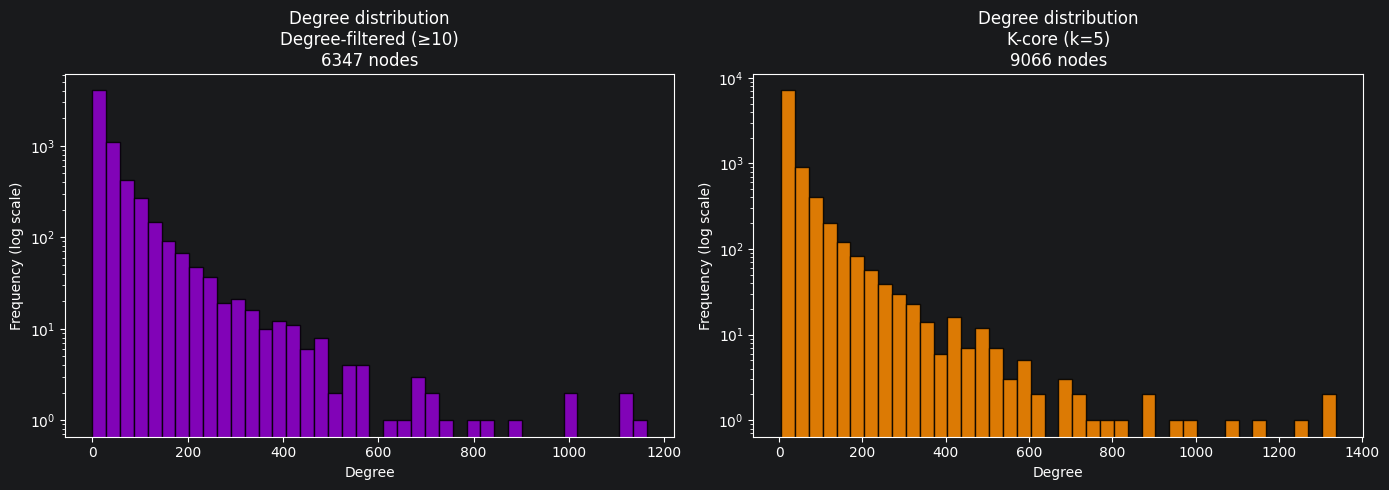


─── Summary comparison ───────────────────────────────
Metric                                 Degree-filtered     K-core
-----------------------------------------------------------------
Nodes                                            6,347      9,066
Edges                                          140,501    160,005
Weakly-connected components                         36          1
Directed density                              0.003488   0.001947
Avg clustering coeff                            0.2863     0.3034


In [5]:
chosen_k = 5   #adjust k value

# k-core directed subgraph
best_core_nodes = nx.k_core(G_und, k=chosen_k).nodes()
G_kcore = G_full.subgraph(best_core_nodes).copy()

print(f"K-core subgraph  (k={chosen_k}): "
      f"{G_kcore.number_of_nodes()} nodes, {G_kcore.number_of_edges()} edges")
print(f"Degree-filtered subgraph (≥10): "
      f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# connected components comparison
kcore_wcc  = nx.number_weakly_connected_components(G_kcore)
degree_wcc = nx.number_weakly_connected_components(G)

print(f"\nWeakly-connected components:")
print(f"  K-core subgraph  : {kcore_wcc}")
print(f"  Degree-filtered  : {degree_wcc}")

# Density compoarison
kcore_density  = nx.density(G_kcore)
degree_density = nx.density(G)

print(f"\nDirected graph density:")
print(f"  K-core subgraph  : {kcore_density:.6f}")
print(f"  Degree-filtered  : {degree_density:.6f}")

# Degree distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, G_sub, label, colour in [
    (axes[0], G,       f"Degree-filtered (≥10)\n{G.number_of_nodes()} nodes",           "darkviolet"),
    (axes[1], G_kcore, f"K-core (k={chosen_k})\n{G_kcore.number_of_nodes()} nodes",     "darkorange"),
]:
    degs = [d for _, d in G_sub.degree()]
    ax.hist(degs, bins=40, color=colour, edgecolor='black', alpha=0.85)
    ax.set_yscale('log')
    ax.set_title(f"Degree distribution\n{label}")
    ax.set_xlabel("Degree")
    ax.set_ylabel("Frequency (log scale)")

plt.tight_layout()
plt.show()


print("Summary ")
print(f"{'Metric':<35} {'Degree-filtered':>18} {'K-core':>10}")
print("-" * 65)
print(f"{'Nodes':<35} {G.number_of_nodes():>18,} {G_kcore.number_of_nodes():>10,}")
print(f"{'Edges':<35} {G.number_of_edges():>18,} {G_kcore.number_of_edges():>10,}")
print(f"{'Weakly-connected components':<35} {degree_wcc:>18} {kcore_wcc:>10}")
print(f"{'Directed density':<35} {degree_density:>18.6f} {kcore_density:>10.6f}")
print(f"{'Avg clustering coeff':<35} "
      f"{nx.average_clustering(G):>18.4f} "
      f"{nx.average_clustering(G_kcore):>10.4f}")


In [6]:
density_full = nx.density(G_full)
density_filtered = nx.density(G)

print(f"Directed density (G_full): {density_full:.8f}")
print(f"Directed density (G, degree>=10): {density_filtered:.8f}")

Directed density (G_full): 0.00007082
Directed density (G, degree>=10): 0.00348828


In [7]:
# Weighted density for directed graph:

def weighted_density_directed(graph, weight_key='Weight'):
    n = graph.number_of_nodes()
    if n < 2:
        return 0.0

    total_possible_directed_edges = n * (n - 1)
    total_weight = sum(float(data.get(weight_key, 0.0)) for _, _, data in graph.edges(data=True))
    return total_weight / total_possible_directed_edges


wd_full = weighted_density_directed(G_full)
wd_filtered = weighted_density_directed(G)

print(f"Weighted density (G_full): {wd_full:.8f}")
print(f"Weighted density (G, degree>=10): {wd_filtered:.8f}")

Weighted density (G_full): 0.00030214
Weighted density (G, degree>=10): 0.01878353


Average In-Degree: 22.14
Average Out-Degree: 22.14


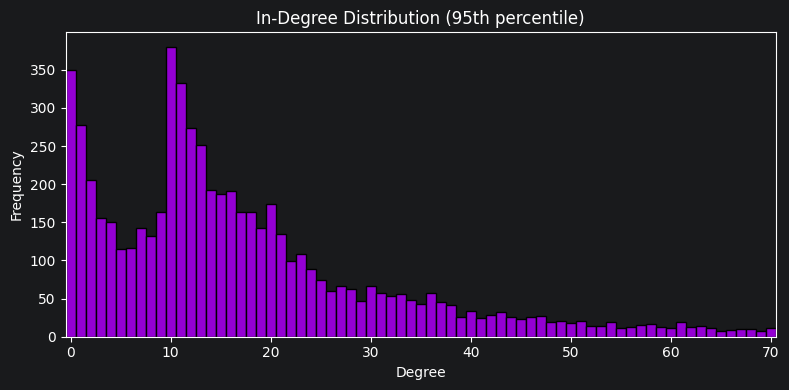

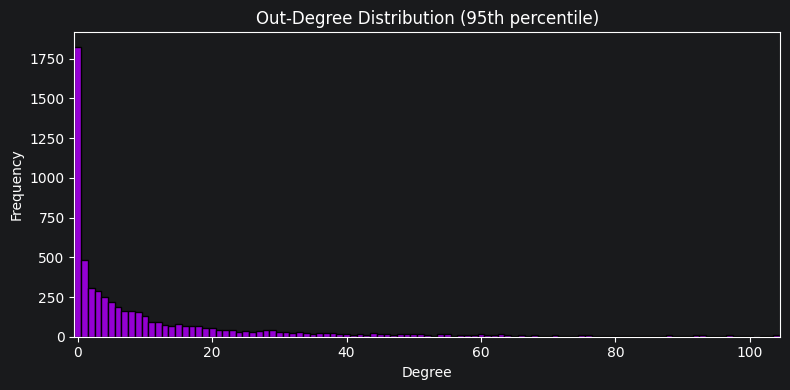

In [8]:
# In-degree and Out-degree distributions
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

avg_in_degree = np.mean(in_degrees)
avg_out_degree = np.mean(out_degrees)

print(f"Average In-Degree: {avg_in_degree:.2f}")
print(f"Average Out-Degree: {avg_out_degree:.2f}")

def plot_dist(data, title, pct=0.99):
    data = np.array(data)
    if len(data) == 0:
        return

    x_max = int(np.ceil(np.quantile(data, pct)))
    x_max = max(x_max, int(data.min()) + 1)

    plt.figure(figsize=(8, 4))
    bins = np.arange(data.min(), x_max + 2) - 0.5
    plt.hist(data, bins=bins, color='darkviolet', edgecolor='black')
    plt.xlim(data.min() - 0.5, x_max + 0.5)
    plt.title(title + f" ({int(pct*100)}th percentile)")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

plot_dist(in_degrees, "In-Degree Distribution", pct=0.95)
plot_dist(out_degrees, "Out-Degree Distribution", pct=0.95)

In [9]:
# Average Clustering Coefficient
avg_clustering = nx.average_clustering(G)
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

Average Clustering Coefficient: 0.2863


In [10]:
# Betweenness Centrality
for u, v, d in G.edges(data=True):
    d['distance'] = 1.0 / d['Weight']

# Calculate betweenness using 'distance' instead of 'Weight'
betweenness = nx.betweenness_centrality(G,  weight='distance')
# Closeness Centrality
closeness = nx.closeness_centrality(G, distance='distance')

In [11]:
# Results
stats_df = pd.DataFrame({
    'Node_ID': list(betweenness.keys()),
    'Betweenness': list(betweenness.values()),
    'Closeness': list(closeness.values()),
    'In_Degree': [G.in_degree(n) for n in G.nodes()],
    'Out_Degree': [G.out_degree(n) for n in G.nodes()]
})

print("Top Influential Nodes by Betweenness:")
top = stats_df.sort_values(by='Betweenness', ascending=False).head(10).reset_index(drop=True)
print(top)

Top Influential Nodes by Betweenness:
   Node_ID  Betweenness  Closeness  In_Degree  Out_Degree
0      585     0.330705   1.318605        457         664
1     4377     0.147937   1.327707        471         541
2     5556     0.124642   1.301513        123         506
3     4404     0.112406   1.328444        439         445
4      802     0.092426   1.320695        170         198
5     3207     0.082051   1.333782        417         411
6    18646     0.081747   1.301561         32          45
7     4390     0.076750   1.321122        370         345
8      743     0.072563   1.316758        106         258
9     1070     0.071464   1.332264        291         413


In [12]:
mapping_df = pd.read_csv("id_mapping.csv")
full_stats_with_names = stats_df.merge(mapping_df, left_on='Node_ID', right_on='ID')
full_stats_with_names = full_stats_with_names.drop(columns=['ID'])
top_10_labeled = full_stats_with_names.sort_values(by='Betweenness', ascending=False).head(10).reset_index(drop=True)
print("--- Top 10 Enron Nodes by Betweenness ---")
print(top_10_labeled[['Email_Address', 'Node_ID', 'Betweenness', 'In_Degree', 'Out_Degree']])

--- Top 10 Enron Nodes by Betweenness ---
               Email_Address  Node_ID  Betweenness  In_Degree  Out_Degree
0    jeff.dasovich@enron.com      585     0.330705        457         664
1       tana.jones@enron.com     4377     0.147937        471         541
2      susan.scott@enron.com     5556     0.124642        123         506
3  sara.shackleton@enron.com     4404     0.112406        439         445
4    james.steffes@enron.com      802     0.092426        170         198
5      mark.taylor@enron.com     3207     0.082051        417         411
6  jeffery.fawcett@enron.com    18646     0.081747         32          45
7     gerald.nemec@enron.com     4390     0.076750        370         345
8  christi.nicolay@enron.com      743     0.072563        106         258
9   louise.kitchen@enron.com     1070     0.071464        291         413


In [13]:
full_stats_with_names['Total_Degree'] = full_stats_with_names['In_Degree'] + full_stats_with_names['Out_Degree']
top_10_total_degree = full_stats_with_names.sort_values(by='Total_Degree', ascending=False).head(10).reset_index(
    drop=True)

print("--- Top 10 Enron Nodes by Total Degree ---")
print(top_10_total_degree[['Node_ID', 'Email_Address', 'Total_Degree', 'In_Degree', 'Out_Degree']])

--- Top 10 Enron Nodes by Total Degree ---
   Node_ID               Email_Address  Total_Degree  In_Degree  Out_Degree
0     1219        sally.beck@enron.com          1163        301         862
1      585     jeff.dasovich@enron.com          1121        457         664
2     3266       kenneth.lay@enron.com          1120        339         781
3     4377        tana.jones@enron.com          1012        471         541
4      886     david.forster@enron.com          1006        159         847
5     4404   sara.shackleton@enron.com           884        439         445
6     3207       mark.taylor@enron.com           828        417         411
7     1700  technology.enron@enron.com           793          0         793
8     3631      outlook.team@enron.com           731         38         693
9     4390      gerald.nemec@enron.com           715        370         345


In [14]:
# Top 10 by Closeness Centrality
top_10_closeness = (
full_stats_with_names.sort_values(by='Closeness', ascending=False).head(10).reset_index(drop=True))

print("--- Top 10 Enron Nodes by Closeness ---")
print(top_10_closeness[['Email_Address', 'Node_ID', 'Closeness', 'In_Degree', 'Out_Degree']])

--- Top 10 Enron Nodes by Closeness ---
                Email_Address  Node_ID  Closeness  In_Degree  Out_Degree
0  william.bradford@enron.com      763   1.347040        145          44
1        tim.belden@enron.com      521   1.343953        239         163
2     john.lavorato@enron.com      998   1.343458        298         373
3      edward.sacks@enron.com      783   1.340803        106          73
4   lisa.mellencamp@enron.com     3190   1.334090        135          85
5       mark.taylor@enron.com     3207   1.333782        417         411
6    barry.tycholiz@enron.com     1406   1.333000        181         121
7    louise.kitchen@enron.com     1070   1.332264        291         413
8   elizabeth.sager@enron.com      609   1.331990        310         241
9     mark.haedicke@enron.com     1393   1.331069        251         296


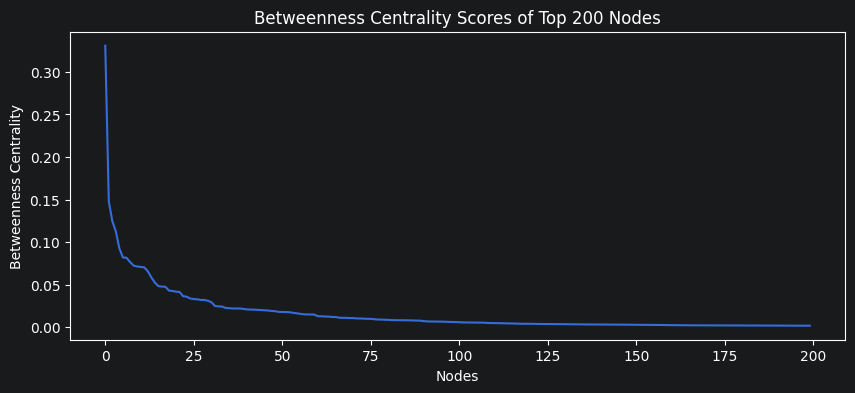

In [15]:
all_scores = sorted(stats_df['Betweenness'], reverse=True)
plt.figure(figsize=(10, 4))
plt.plot(all_scores[:200])
plt.title("Betweenness Centrality Scores of Top 200 Nodes")
plt.xlabel("Nodes")
plt.ylabel("Betweenness Centrality")
plt.show()

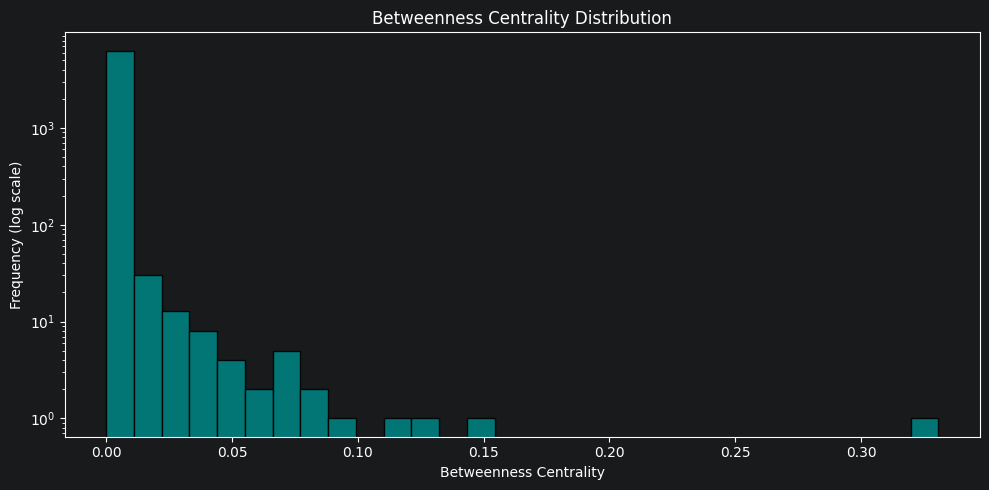

In [16]:
# Distribution of Betweenness Centrality
plt.figure(figsize=(10, 5))
plt.hist(stats_df['Betweenness'], bins=30, color='teal', edgecolor='black', alpha=0.9)
plt.yscale('log')
plt.title("Betweenness Centrality Distribution")
plt.xlabel("Betweenness Centrality")
plt.ylabel("Frequency (log scale)")
plt.tight_layout()
plt.show()

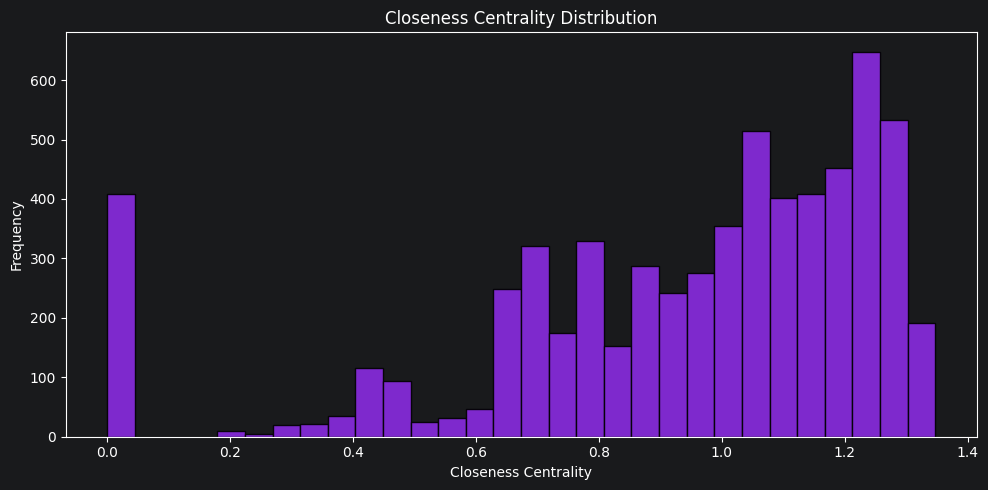

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(stats_df['Closeness'], bins=30, color='blueviolet', edgecolor='black', alpha=0.9)
plt.title("Closeness Centrality Distribution")
plt.xlabel("Closeness Centrality")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

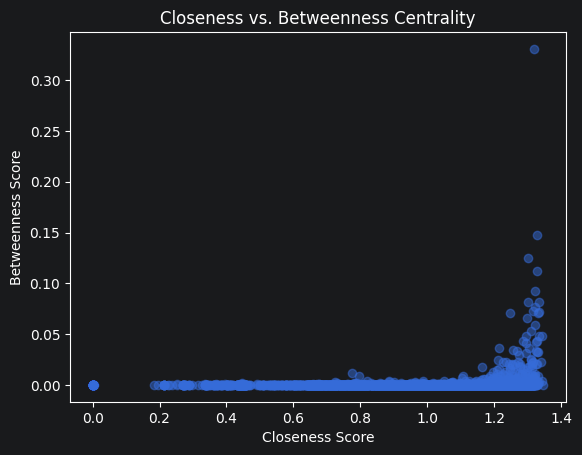

In [18]:
plt.scatter(stats_df['Closeness'], stats_df['Betweenness'], alpha=0.5)
plt.title("Closeness vs. Betweenness Centrality")
plt.xlabel("Closeness Score")
plt.ylabel("Betweenness Score")
plt.show()

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CENTRALITY ANALYSIS ON K-CORE SUBGRAPH
# Mirrors the same weighted approach used for the degree-filtered subgraph.
# 'distance' = 1 / Weight so that heavily-used edges are treated as SHORT.
# ─────────────────────────────────────────────────────────────────────────────

# Add distance attribute to k-core edges
for u, v, d in G_kcore.edges(data=True):
    d['distance'] = 1.0 / d['Weight']

print("Computing betweenness centrality on k-core subgraph … (may take a moment)")
betweenness_kcore = nx.betweenness_centrality(G_kcore, weight='distance')

print("Computing closeness centrality on k-core subgraph …")
closeness_kcore = nx.closeness_centrality(G_kcore, distance='distance')

# Build stats dataframe
kcore_stats_df = pd.DataFrame({
    'Node_ID':    list(betweenness_kcore.keys()),
    'Betweenness': list(betweenness_kcore.values()),
    'Closeness':   list(closeness_kcore.values()),
    'In_Degree':  [G_kcore.in_degree(n)  for n in G_kcore.nodes()],
    'Out_Degree': [G_kcore.out_degree(n) for n in G_kcore.nodes()],
})

# Merge with email labels
kcore_stats_named = kcore_stats_df.merge(mapping_df, left_on='Node_ID', right_on='ID').drop(columns=['ID'])
kcore_stats_named['Total_Degree'] = kcore_stats_named['In_Degree'] + kcore_stats_named['Out_Degree']

print("Done.")


Computing betweenness centrality on k-core subgraph … (may take a moment)
Computing closeness centrality on k-core subgraph …
Done.


In [20]:
# ── Top 10 by Betweenness ──────────────────────────────────────────────────
top10_bt_kcore = (
    kcore_stats_named
    .sort_values('Betweenness', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print("--- K-core: Top 10 Nodes by Betweenness ---")
print(top10_bt_kcore[['Email_Address', 'Node_ID', 'Betweenness', 'In_Degree', 'Out_Degree']])

print()

# ── Top 10 by Total Degree ────────────────────────────────────────────────
top10_deg_kcore = (
    kcore_stats_named
    .sort_values('Total_Degree', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print("--- K-core: Top 10 Nodes by Total Degree ---")
print(top10_deg_kcore[['Node_ID', 'Email_Address', 'Total_Degree', 'In_Degree', 'Out_Degree']])

print()

# ── Top 10 by Closeness ───────────────────────────────────────────────────
top10_cl_kcore = (
    kcore_stats_named
    .sort_values('Closeness', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print("--- K-core: Top 10 Nodes by Closeness ---")
print(top10_cl_kcore[['Email_Address', 'Node_ID', 'Closeness', 'In_Degree', 'Out_Degree']])


--- K-core: Top 10 Nodes by Betweenness ---
               Email_Address  Node_ID  Betweenness  In_Degree  Out_Degree
0    jeff.dasovich@enron.com      585     0.255010        478         783
1       tana.jones@enron.com     4377     0.112113        495         591
2      susan.scott@enron.com     5556     0.091321        127         555
3  sara.shackleton@enron.com     4404     0.081260        473         479
4    james.steffes@enron.com      802     0.070022        172         207
5      mark.taylor@enron.com     3207     0.063355        436         446
6  jeffery.fawcett@enron.com    18646     0.062216         32          46
7   louise.kitchen@enron.com     1070     0.056581        294         437
8  elizabeth.sager@enron.com      609     0.056353        320         251
9     gerald.nemec@enron.com     4390     0.054666        385         362

--- K-core: Top 10 Nodes by Total Degree ---
   Node_ID               Email_Address  Total_Degree  In_Degree  Out_Degree
0     1219        sa

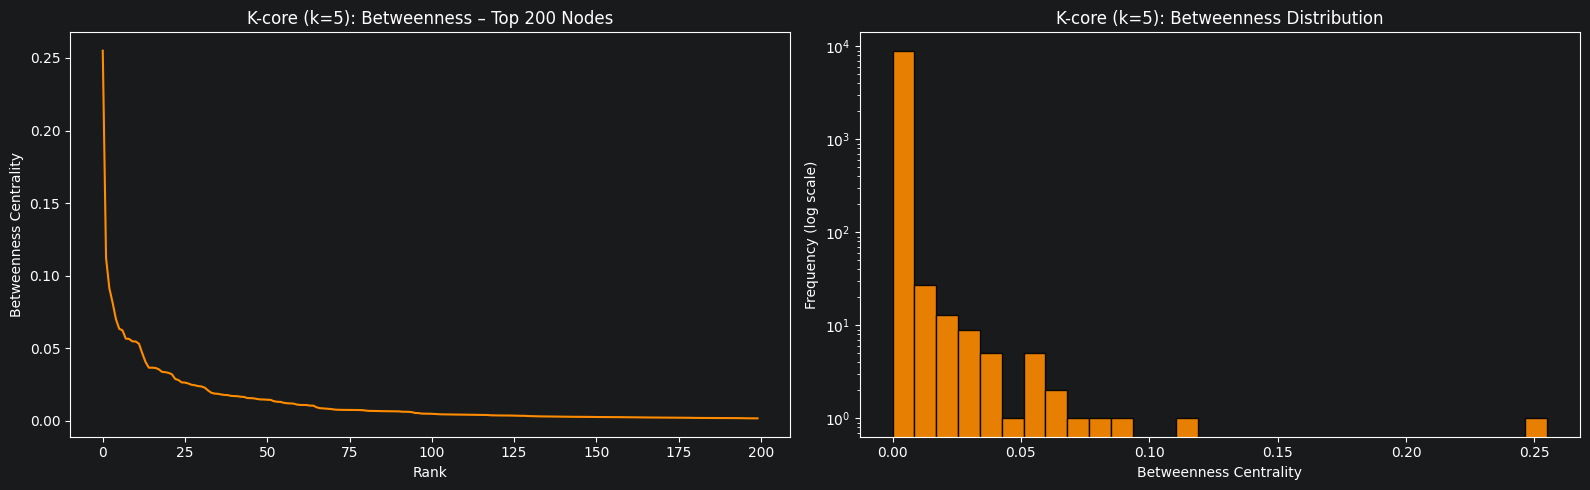

In [21]:
# ── Betweenness: top-200 line + distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top-200 rank plot
all_bt_kcore = sorted(kcore_stats_df['Betweenness'], reverse=True)
axes[0].plot(all_bt_kcore[:200], color='darkorange')
axes[0].set_title(f"K-core (k={chosen_k}): Betweenness – Top 200 Nodes")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Betweenness Centrality")

# Distribution
axes[1].hist(kcore_stats_df['Betweenness'], bins=30,
             color='darkorange', edgecolor='black', alpha=0.9)
axes[1].set_yscale('log')
axes[1].set_title(f"K-core (k={chosen_k}): Betweenness Distribution")
axes[1].set_xlabel("Betweenness Centrality")
axes[1].set_ylabel("Frequency (log scale)")

plt.tight_layout()
plt.show()


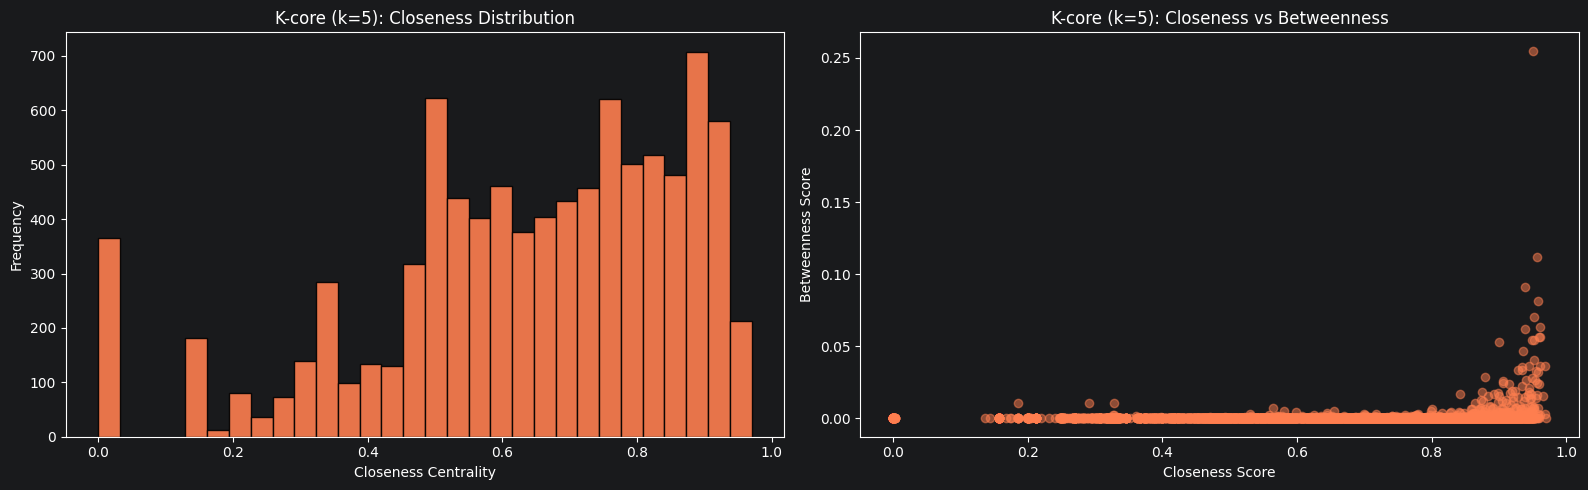

In [22]:
# ── Closeness distribution + Closeness vs Betweenness scatter ────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Closeness distribution
axes[0].hist(kcore_stats_df['Closeness'], bins=30,
             color='coral', edgecolor='black', alpha=0.9)
axes[0].set_title(f"K-core (k={chosen_k}): Closeness Distribution")
axes[0].set_xlabel("Closeness Centrality")
axes[0].set_ylabel("Frequency")

# Scatter: Closeness vs Betweenness
axes[1].scatter(kcore_stats_df['Closeness'], kcore_stats_df['Betweenness'],
                alpha=0.5, color='coral')
axes[1].set_title(f"K-core (k={chosen_k}): Closeness vs Betweenness")
axes[1].set_xlabel("Closeness Score")
axes[1].set_ylabel("Betweenness Score")

plt.tight_layout()
plt.show()


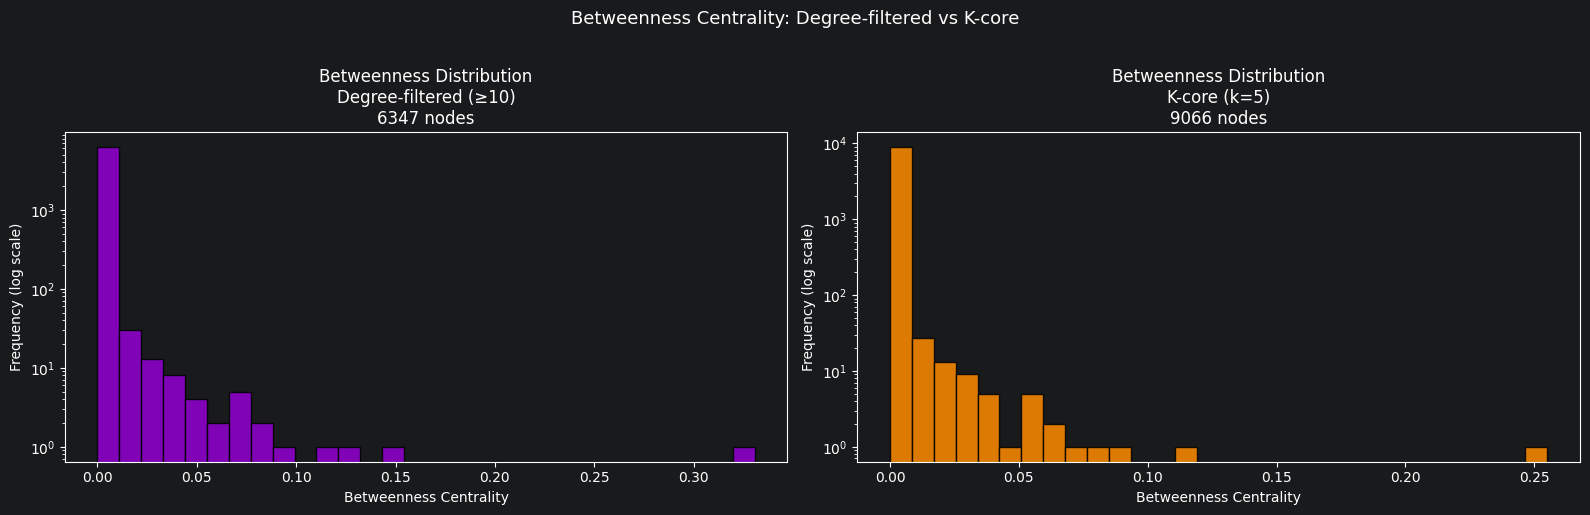


Metric                                           Degree-filtered     K-core
---------------------------------------------------------------------------
Max betweenness                                         0.330705   0.255010
Mean betweenness                                        0.000596   0.000327
Median betweenness                                      0.000000   0.000000
Max closeness                                           1.347040   0.970310
Mean closeness                                          0.931138   0.635902


In [23]:
# ── Side-by-side comparison: Degree-filtered vs K-core betweenness ────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, scores, label, colour in [
    (axes[0], sorted(stats_df['Betweenness'],        reverse=True),
     f"Degree-filtered (≥10)\n{G.number_of_nodes()} nodes",           'darkviolet'),
    (axes[1], sorted(kcore_stats_df['Betweenness'],  reverse=True),
     f"K-core (k={chosen_k})\n{G_kcore.number_of_nodes()} nodes",     'darkorange'),
]:
    ax.hist(scores, bins=30, color=colour, edgecolor='black', alpha=0.85)
    ax.set_yscale('log')
    ax.set_title(f"Betweenness Distribution\n{label}")
    ax.set_xlabel("Betweenness Centrality")
    ax.set_ylabel("Frequency (log scale)")

plt.suptitle("Betweenness Centrality: Degree-filtered vs K-core", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Print key stats side by side ─────────────────────────────────────────
print(f"\n{'Metric':<45} {'Degree-filtered':>18} {'K-core':>10}")
print("-" * 75)
for label, col_df, col_kc in [
    ('Max betweenness',    stats_df['Betweenness'].max(),    kcore_stats_df['Betweenness'].max()),
    ('Mean betweenness',   stats_df['Betweenness'].mean(),   kcore_stats_df['Betweenness'].mean()),
    ('Median betweenness', stats_df['Betweenness'].median(), kcore_stats_df['Betweenness'].median()),
    ('Max closeness',      stats_df['Closeness'].max(),      kcore_stats_df['Closeness'].max()),
    ('Mean closeness',     stats_df['Closeness'].mean(),     kcore_stats_df['Closeness'].mean()),
]:
    print(f"{label:<45} {col_df:>18.6f} {col_kc:>10.6f}")
